# 02 — Preprocessing & Feature Engineering
## EV Charger Reliability Analytics

This notebook walks through the data preprocessing, connection flattening, feature encoding, and numeric imputation steps. It also documents the critical **data leakage guards** applied to prevent the model from using post-event metadata.


## 1. Setup & Imports

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path().resolve().parent))

ROOT = Path().resolve().parent
PROC = ROOT / "data" / "processed"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Plot settings
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
})

print("Imports ready.")


Imports ready.


## 2. Interactive Preprocessing

We execute the preprocessing pipeline defined in `src/preprocess.py`. This extracts the features and labels, saves them to `data/processed/`, and returns the feature matrices.


In [2]:
from src.preprocess import preprocess

# Run the preprocessing to generate the processed CSV files
print("Running preprocessing pipeline...")
X_geo, y = preprocess(include_country=True)
X_nogeo, _ = preprocess(include_country=False)

print(f"\nProcessed Features (with country): {X_geo.shape}")
print(f"Processed Features (without country): {X_nogeo.shape}")
print(f"Target variable shape: {y.shape}")


Running preprocessing pipeline...


2026-07-12 13:39:26 [INFO] Loaded labeled dataset: 10330 records


2026-07-12 13:39:26 [INFO] Target — Operational: 10114 | Non-Operational: 216


2026-07-12 13:39:26 [INFO] Flattening 'Connections' column with ast.literal_eval() …


2026-07-12 13:39:28 [INFO] Connection features added: ['max_power_kw', 'primary_connection_type_id', 'n_distinct_connection_types', 'max_amps', 'max_voltage', 'primary_current_type_id', 'n_connections', 'has_fast_charger', 'has_dc_fast']


...

2026-07-12 13:39:30 [INFO] Leakage guard passed — no excluded columns in feature matrix.


2026-07-12 13:39:30 [INFO] Feature matrix: 10330 rows × 18 columns


2026-07-12 13:39:30 [INFO] Features: ['operator_id', 'usage_type_id', 'country_id', 'number_of_points', 'data_provider_id', 'max_power_kw', 'primary_connection_type_id', 'n_distinct_connection_types', 'max_amps', 'max_voltage', 'primary_current_type_id', 'n_connections', 'has_fast_charger', 'has_dc_fast', 'operator_title_enc', 'usage_type_title_enc', 'state_or_province_enc', 'town_freq']


2026-07-12 13:39:30 [INFO] Saved features_without_country.csv, target.csv, encoder map.



Processed Features (with country): (10330, 19)
Processed Features (without country): (10330, 18)
Target variable shape: (10330,)


## 3. Connection Flattening Audit

Here, we inspect the flattened connection characteristics extracted using `ast.literal_eval()` from the raw API structure.


In [3]:
conn_cols = [
    "max_power_kw",
    "primary_connection_type_id",
    "n_distinct_connection_types",
    "max_amps",
    "max_voltage",
    "primary_current_type_id",
    "n_connections",
    "has_fast_charger",
    "has_dc_fast"
]
print("Aggregated Connection Features statistics:")
print(X_geo[conn_cols].describe().T)


Aggregated Connection Features statistics:
                               count        mean         std   min    25%  \
max_power_kw                 10330.0   93.217881  313.152145   0.0   22.0   
primary_connection_type_id   10330.0  134.564279  314.720905   0.0   25.0   
n_distinct_connection_types  10330.0    1.377735    0.687782   0.0    1.0   
max_amps                     10330.0   57.871733   90.366796  -4.0   32.0   
max_voltage                  10330.0  423.837367  160.431411  -4.0  400.0   
primary_current_type_id      10330.0   24.871249    6.672561  10.0   20.0   
n_connections                10330.0    1.625460    1.271990   0.0    1.0   
has_fast_charger             10330.0    0.484898    0.499796   0.0    0.0   
has_dc_fast                  10330.0    0.465924    0.498862   0.0    0.0   

                               50%    75%      max  
max_power_kw                  50.0  150.0  30000.0  
primary_connection_type_id    33.0   33.0   1041.0  
n_distinct_connection_types

## 4. Correlation Analysis

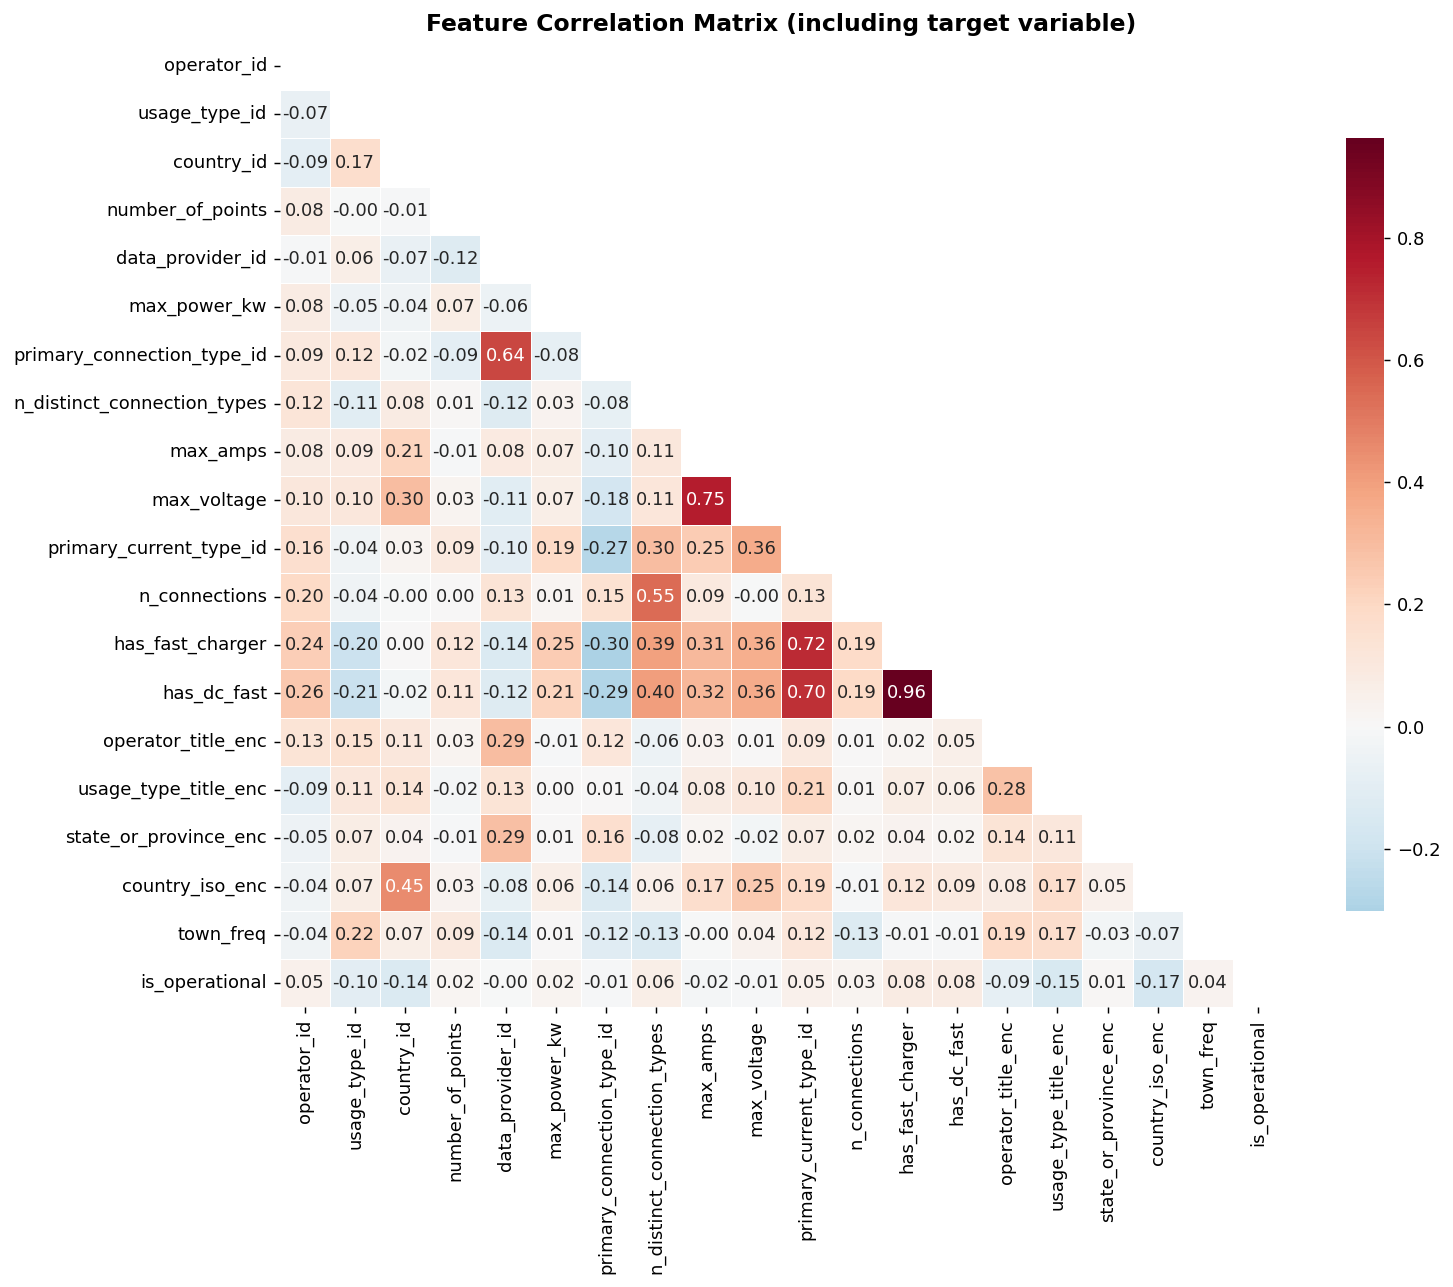

In [4]:
# Check linear correlation of continuous features with the target variable
df_corr = X_geo.copy()
df_corr["is_operational"] = y

plt.figure(figsize=(12, 10))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matrix (including target variable)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "17_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Leakage Exclusion Guarantees

We enforce strict data leakage exclusions. The following columns have been audited and are guaranteed to be absent from both feature matrices:

1. **`StatusTypeID` / `StatusType.Title`** — Direct target leakage.
2. **`DateLastStatusUpdate`** — Direct temporal leakage (updated post-event).
3. **`DateLastVerified` / `DateLastConfirmed`** — Direct temporal proxy for station activity.
4. **`GeneralComments` / `UserComments`** — Natural language leakage containing status descriptions.
5. **`DateCreated`** — Temporal confounding variable.
